# 12-security PennyLane QAOA processor with optimization reporting

This notebook is aligned to the 12-security demo workbook and uses:

- PennyLane
- `lightning.qubit` as the simulator
- full-universe QAOA on all binary decision variables
- **QAOA with configurable p**
- live optimization reporting
- top-N portfolio output
- optimization history export
- **QUBO term decomposition per solution**
- **no additional same-asset block exclusivity constraint**

## Output sheets
- `Results_Summary`
- `Results_Overview`
- `Results_Portfolios`
- `Solver_Comparison`
- `Classical_Candidates`
- `QAOA_Samples`
- `Optimization_History`

In addition to the total QUBO value, the notebook reports for each solution:

- `return_term`
- `risk_term`
- `budget_term`
- `exclusivity_term` which is now expected to stay at zero unless reintroduced deliberately
- reconstructed QUBO total
- average term contribution per selected option


In [1]:
#!pip -q install yfinance openpyxl pandas numpy scipy matplotlib pennylane pennylane-lightning

In [2]:
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill

from scipy.optimize import minimize

import pennylane as qml

In [3]:
xlsx_path = Path("demo_budget_block_options_12sec_pennylane_p2_splitterms.xlsx")

TOP_N_EXPORT = 20
REFRESH_OVERRIDE = None
ENABLE_QAOA = True
QAOA_P = 1
QAOA_MAXITER = 60
RANDOM_SEARCH_SAMPLES = 8000
LOCAL_SEARCH_STARTS = 40
RNG_SEED = 42

random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

xlsx_path


PosixPath('demo_budget_block_options_12sec_pennylane_p2_splitterms.xlsx')

In [4]:
xls = pd.ExcelFile(xlsx_path)

assets_df = pd.read_excel(xls, sheet_name="Assets", header=1)
settings_df = pd.read_excel(xls, sheet_name="Settings", header=1)
settings = dict(zip(settings_df["Key"], settings_df["Value"]))

blockoptions_df = None
if "BlockOptions" in xls.sheet_names:
    blockoptions_df = pd.read_excel(xls, sheet_name="BlockOptions", header=1)

display(assets_df.head())
if blockoptions_df is not None:
    display(blockoptions_df.head())
display(settings_df)


,Ticker,Company,Current Price (USD),Price Source Status,12M Return Proxy,Annual Volatility,Mean Daily Return,Std Daily Return,Allowed,Source URL
0,NVDA,NVIDIA,199.430099,Imported via yfinance,0.909054,0.341897,0.002820,0.021538,1,https://pypi.org/project/yfinance/
1,AAPL,Apple,262.440002,Imported via yfinance,0.356791,0.235374,0.001330,0.014827,1,https://pypi.org/project/yfinance/
2,MSFT,Microsoft,416.899994,Imported via yfinance,0.130464,0.244579,0.000610,0.015407,1,https://pypi.org/project/yfinance/
3,AVGO,Broadcom,399.299988,Imported via yfinance,1.305339,0.427863,0.003705,0.026953,1,https://pypi.org/project/yfinance/
4,MU,Micron Technology,457.359985,Imported via yfinance,5.612645,0.589799,0.008267,0.037154,1,https://pypi.org/project/yfinance/


,decision_id,Ticker,Block Label,Target Block USD,Shares,Approx Cost USD,Allowed,Asset Group,Expected Return Proxy,Annual Volatility
0,NVDA_100k,NVDA,100k,100000,501,99914.479843,1,NVDA,0.909054,0.341897
1,NVDA_150k,NVDA,150k,150000,752,149971.434814,1,NVDA,0.909054,0.341897
2,AAPL_100k,AAPL,100k,100000,381,99989.640930,1,AAPL,0.356791,0.235374
3,AAPL_150k,AAPL,150k,150000,572,150115.681396,1,AAPL,0.356791,0.235374
4,MSFT_100k,MSFT,100k,100000,240,100055.998535,1,MSFT,0.130464,0.244579


,Key,Value,Description
0,budget_usd,1000000.00,Target total budget
1,risk_free_rate_annual,0.04,Annual risk-free rate used in excess-return re...
2,lambda_budget,50.00,Budget deviation penalty
3,lambda_variance,6.00,Variance contribution weight
4,lambda_exclusive,20.00,Penalty for selecting more than one block opti...
5,top_n_export,20.00,Target number of candidate portfolios to export


In [5]:
refresh_from_settings = False
if "refresh_market_data" in settings:
    refresh_from_settings = bool(int(settings.get("refresh_market_data", 0)))

REFRESH_WITH_YFINANCE = refresh_from_settings if REFRESH_OVERRIDE is None else bool(REFRESH_OVERRIDE)
REFRESH_WITH_YFINANCE

False

In [6]:
if REFRESH_WITH_YFINANCE:
    tickers = assets_df.loc[assets_df["Allowed"] == 1, "Ticker"].dropna().astype(str).tolist()

    prices = yf.download(
        tickers=tickers,
        period="12mo",
        interval="1d",
        auto_adjust=True,
        progress=False,
    )["Close"]

    if isinstance(prices, pd.Series):
        prices = prices.to_frame()

    prices = prices.dropna(how="all").ffill().dropna()
    rets = prices.pct_change().dropna()

    total_return_12m = prices.iloc[-1] / prices.iloc[0] - 1
    ann_vol = rets.std() * np.sqrt(252)
    daily_cov = rets.cov()
    annual_cov = daily_cov * 252

    wb = load_workbook(xlsx_path)
    sh_assets = wb["Assets"]
    sh_returns = wb["Returns"]
    sh_cov = wb["Covariance"]
    sh_acov = wb["AnnualizedCovariance"]
    sh_ph = wb["PriceHistory"]

    for row in sh_ph.iter_rows(min_row=3, max_row=5000, min_col=1, max_col=1 + len(tickers)):
        for cell in row:
            cell.value = None

    for r_idx, dt in enumerate(prices.index, start=3):
        sh_ph.cell(r_idx, 1, dt.to_pydatetime())
        for c_idx, t in enumerate(tickers, start=2):
            sh_ph.cell(r_idx, c_idx, float(prices.loc[dt, t]))

    for idx, t in enumerate(tickers, start=3):
        sh_assets.cell(idx, 3, float(prices[t].iloc[-1]))
        sh_assets.cell(idx, 4, "Refreshed with yfinance")
        sh_assets.cell(idx, 5, float(total_return_12m[t]))
        sh_assets.cell(idx, 6, float(ann_vol[t]))
        sh_assets.cell(idx, 7, float(rets[t].mean()))
        sh_assets.cell(idx, 8, float(rets[t].std()))
        sh_returns.cell(idx, 2, float(total_return_12m[t]))
        sh_returns.cell(idx, 3, float(ann_vol[t]))
        sh_returns.cell(idx, 4, float(rets[t].mean()))
        sh_returns.cell(idx, 5, float(rets[t].std()))
        sh_returns.cell(idx, 6, "Refreshed with yfinance")

    for i, tr in enumerate(tickers, start=3):
        for j, tc in enumerate(tickers, start=2):
            sh_cov.cell(i, j, float(daily_cov.loc[tr, tc]))
            sh_acov.cell(i, j, float(annual_cov.loc[tr, tc]))

    wb.save(xlsx_path)

    xls = pd.ExcelFile(xlsx_path)
    assets_df = pd.read_excel(xls, sheet_name="Assets", header=1)
    settings_df = pd.read_excel(xls, sheet_name="Settings", header=1)
    settings = dict(zip(settings_df["Key"], settings_df["Value"]))

    print(f"Workbook refreshed and saved to {xlsx_path.resolve()}")

In [7]:
assets_df = assets_df.loc[assets_df["Ticker"].notna()].copy()
assets_df["Ticker"] = assets_df["Ticker"].astype(str)

if "Allowed" in assets_df.columns:
    assets_df = assets_df.loc[assets_df["Allowed"].fillna(1).astype(int) == 1].copy()

for col in ["Current Price (USD)", "12M Return Proxy", "Annual Volatility"]:
    if col in assets_df.columns:
        assets_df[col] = pd.to_numeric(assets_df[col], errors="coerce")

budget_usd = float(settings["budget_usd"])
risk_free = float(settings["risk_free_rate_annual"])
lambda_budget = float(settings["lambda_budget"])
lambda_variance = float(settings["lambda_variance"])
lambda_exclusive = 0.0

ticker_to_company = {}
if "Company" in assets_df.columns:
    ticker_to_company = (
        assets_df[["Ticker", "Company"]]
        .dropna(subset=["Ticker"])
        .drop_duplicates(subset=["Ticker"])
        .set_index("Ticker")["Company"]
        .to_dict()
    )

if blockoptions_df is not None:
    blocks_df = blockoptions_df.copy()
else:
    blocks_df = assets_df.copy()

blocks_df = blocks_df.loc[blocks_df["Ticker"].notna()].copy()
blocks_df["Ticker"] = blocks_df["Ticker"].astype(str)

if "Allowed" in blocks_df.columns:
    blocks_df = blocks_df.loc[blocks_df["Allowed"].fillna(1).astype(int) == 1].copy()

required_option_cols = ["Ticker", "Approx Cost USD", "Expected Return Proxy", "Annual Volatility"]
missing_option_cols = [c for c in required_option_cols if c not in blocks_df.columns]
if missing_option_cols:
    raise ValueError(
        "Input Excel must define the selectable options directly. "
        f"Missing required columns in BlockOptions/Assets sheet: {missing_option_cols}"
    )

for col in ["Approx Cost USD", "Expected Return Proxy", "Annual Volatility"]:
    blocks_df[col] = pd.to_numeric(blocks_df[col], errors="coerce")

if blocks_df["Approx Cost USD"].isna().any():
    bad = blocks_df.loc[blocks_df["Approx Cost USD"].isna(), "Ticker"].tolist()
    raise ValueError(f"Approx Cost USD missing for options: {bad}")

if (blocks_df["Approx Cost USD"] <= 0).any():
    bad = blocks_df.loc[blocks_df["Approx Cost USD"] <= 0, ["Ticker", "Approx Cost USD"]]
    raise ValueError(f"Approx Cost USD must be > 0 for all options. Bad rows:\n{bad}")

if "decision_id" not in blocks_df.columns:
    blocks_df["decision_id"] = [
        f"{ticker}_opt{i+1}" for i, ticker in enumerate(blocks_df["Ticker"].tolist())
    ]
else:
    blocks_df["decision_id"] = blocks_df["decision_id"].astype(str)

if "Company" not in blocks_df.columns:
    blocks_df["Company"] = blocks_df["Ticker"].map(ticker_to_company)

if "Block Label" not in blocks_df.columns:
    blocks_df["Block Label"] = ""

if "Shares" not in blocks_df.columns:
    blocks_df["Shares"] = np.nan

if "Asset Group" not in blocks_df.columns:
    blocks_df["Asset Group"] = blocks_df["Ticker"]

blocks_df = blocks_df.reset_index(drop=True)

annual_cov_df = pd.read_excel(xls, sheet_name="AnnualizedCovariance", header=1)
annual_cov_df = annual_cov_df.rename(columns={annual_cov_df.columns[0]: "Ticker"})
annual_cov_df = annual_cov_df.loc[annual_cov_df["Ticker"].notna()].copy()
annual_cov_df["Ticker"] = annual_cov_df["Ticker"].astype(str)
annual_cov_df = annual_cov_df.set_index("Ticker")

asset_universe = list(dict.fromkeys(blocks_df["Ticker"].tolist()))
missing_cov_assets = [t for t in asset_universe if t not in annual_cov_df.index or t not in annual_cov_df.columns]
if missing_cov_assets:
    raise ValueError(
        "AnnualizedCovariance sheet is missing these tickers used by the options: "
        + ", ".join(missing_cov_assets)
    )

Sigma_assets = annual_cov_df.loc[asset_universe, asset_universe].to_numpy(dtype=float)
ticker_to_idx = {t: i for i, t in enumerate(asset_universe)}

decision_ids = blocks_df["decision_id"].tolist()
opt_tickers = blocks_df["Ticker"].tolist()
opt_cost = blocks_df["Approx Cost USD"].astype(float).to_numpy()
opt_ret = blocks_df["Expected Return Proxy"].astype(float).to_numpy()

n = len(blocks_df)
Sigma_opt = np.zeros((n, n), dtype=float)
for i in range(n):
    ai = ticker_to_idx[opt_tickers[i]]
    for j in range(n):
        aj = ticker_to_idx[opt_tickers[j]]
        Sigma_opt[i, j] = Sigma_assets[ai, aj]

print(f"Assets referenced by options: {len(asset_universe)}")
print(f"Decision variables from Excel: {n}")
print(f"QAOA layers p: {QAOA_P}")
display(blocks_df.head(10))


Assets referenced by options: 12
Decision variables from Excel: 24
QAOA layers p: 1


,decision_id,Ticker,Block Label,Target Block USD,Shares,Approx Cost USD,Allowed,Asset Group,Expected Return Proxy,Annual Volatility,Company
0,NVDA_100k,NVDA,100k,100000,501,99914.479843,1,NVDA,0.909054,0.341897,NVIDIA
1,NVDA_150k,NVDA,150k,150000,752,149971.434814,1,NVDA,0.909054,0.341897,NVIDIA
2,AAPL_100k,AAPL,100k,100000,381,99989.640930,1,AAPL,0.356791,0.235374,Apple
3,AAPL_150k,AAPL,150k,150000,572,150115.681396,1,AAPL,0.356791,0.235374,Apple
4,MSFT_100k,MSFT,100k,100000,240,100055.998535,1,MSFT,0.130464,0.244579,Microsoft
5,MSFT_150k,MSFT,150k,150000,360,150083.997803,1,MSFT,0.130464,0.244579,Microsoft
6,AVGO_100k,AVGO,100k,100000,250,99824.996948,1,AVGO,1.305339,0.427863,Broadcom
7,AVGO_150k,AVGO,150k,150000,376,150136.795410,1,AVGO,1.305339,0.427863,Broadcom
8,MU_100k,MU,100k,100000,219,100161.836792,1,MU,5.612645,0.589799,Micron Technology
9,MU_150k,MU,150k,150000,328,150014.075195,1,MU,5.612645,0.589799,Micron Technology


In [8]:
def build_qubo_budget_first(opt_ret, risk_free, opt_cost, Sigma_opt, budget_usd,
                             lambda_budget, lambda_variance, lambda_exclusive, opt_tickers):
    n = len(opt_ret)
    Q = np.zeros((n, n), dtype=float)

    scaled_cost = opt_cost / float(budget_usd)

    ret_excess = opt_ret - risk_free
    ret_scale = np.max(np.abs(ret_excess)) + 1e-12
    ret_scaled = ret_excess / ret_scale

    sigma_scale = np.max(np.abs(Sigma_opt)) + 1e-12
    Sigma_scaled = Sigma_opt / sigma_scale

    reward = ret_scaled * scaled_cost
    for i in range(n):
        Q[i, i] += -reward[i]

    for i in range(n):
        Q[i, i] += lambda_variance * (scaled_cost[i] ** 2) * Sigma_scaled[i, i]
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] += 2.0 * lambda_variance * scaled_cost[i] * scaled_cost[j] * Sigma_scaled[i, j]

    for i in range(n):
        Q[i, i] += lambda_budget * (scaled_cost[i] ** 2 - 2.0 * scaled_cost[i])
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] += 2.0 * lambda_budget * scaled_cost[i] * scaled_cost[j]
    constant = float(lambda_budget)

    lambda_exclusive_effective = 0.0

    qubo_meta = {
        "scaled_cost": scaled_cost,
        "ret_scaled": ret_scaled,
        "Sigma_scaled": Sigma_scaled,
        "lambda_budget": float(lambda_budget),
        "lambda_variance": float(lambda_variance),
        "lambda_exclusive": float(lambda_exclusive_effective),
        "opt_tickers": list(opt_tickers),
        "budget_usd": float(budget_usd),
        "ret_scale": float(ret_scale),
        "sigma_scale": float(sigma_scale),
    }

    return Q, constant, qubo_meta

Q, constant, qubo_meta = build_qubo_budget_first(
    opt_ret, risk_free, opt_cost, Sigma_opt, budget_usd,
    lambda_budget, lambda_variance, lambda_exclusive, opt_tickers
)

pd.DataFrame(Q, index=decision_ids, columns=decision_ids).iloc[:10, :10]


,NVDA_100k,NVDA_150k,AAPL_100k,AAPL_150k,MSFT_100k,MSFT_150k,AVGO_100k,AVGO_150k,MU_100k,MU_150k
NVDA_100k,-9.490616,1.550273,1.005824,1.510056,1.010176,1.515264,1.023242,1.538956,1.029776,1.542313
NVDA_150k,0.000000,-13.857054,1.509740,2.266591,1.516272,2.274408,1.535884,2.309970,1.545691,2.315008
AAPL_100k,0.000000,0.000000,-9.496555,1.525613,1.003345,1.505017,1.005184,1.511797,1.008883,1.511022
AAPL_150k,0.000000,0.000000,0.000000,-13.874891,1.506334,2.259500,1.509095,2.269679,1.514649,2.268516
MSFT_100k,0.000000,0.000000,0.000000,0.000000,-9.497802,1.528267,1.009607,1.518450,1.009704,1.512251
MSFT_150k,0.000000,0.000000,0.000000,0.000000,0.000000,-13.864636,1.514411,2.277674,1.514556,2.268377
AVGO_100k,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.479919,1.579944,1.033330,1.547636
AVGO_150k,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-13.859652,1.554129,2.327645
MU_100k,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.563081,1.657266
MU_150k,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-13.910364


In [9]:
def qubo_value(bitvec, Q, constant=0.0):
    x = np.asarray(bitvec, dtype=float)
    return float(x @ Q @ x + constant)

def qubo_term_breakdown(bitvec, qubo_meta):
    x = np.asarray(bitvec, dtype=float)

    scaled_cost = np.asarray(qubo_meta["scaled_cost"], dtype=float)
    ret_scaled = np.asarray(qubo_meta["ret_scaled"], dtype=float)
    Sigma_scaled = np.asarray(qubo_meta["Sigma_scaled"], dtype=float)
    lambda_budget = float(qubo_meta["lambda_budget"])
    lambda_variance = float(qubo_meta["lambda_variance"])

    num_selected = int(x.sum())

    return_term = float(-np.dot(ret_scaled * scaled_cost, x))
    weighted = x * scaled_cost
    risk_term = float(lambda_variance * (weighted @ Sigma_scaled @ weighted))
    budget_term = float(lambda_budget * (weighted.sum() - 1.0) ** 2)
    exclusivity_term = 0.0

    total = float(return_term + risk_term + budget_term + exclusivity_term)

    denom = max(num_selected, 1)
    return {
        "return_term": return_term,
        "risk_term": risk_term,
        "budget_term": budget_term,
        "exclusivity_term": exclusivity_term,
        "qubo_reconstructed": total,
        "avg_return_term_per_option": float(return_term / denom),
        "avg_risk_term_per_option": float(risk_term / denom),
        "avg_budget_term_per_option": float(budget_term / denom),
        "avg_exclusivity_term_per_option": 0.0,
    }

def portfolio_stats(bitvec, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd):
    x = np.asarray(bitvec, dtype=float)
    selected_cost = x * opt_cost
    total = float(selected_cost.sum())
    num_selected = int(x.sum())

    if total <= 0:
        return {
            "selected_usd": 0.0,
            "budget_gap": -budget_usd,
            "abs_budget_gap": abs(-budget_usd),
            "num_options": 0,
            "num_distinct_assets": 0,
            "portfolio_return": 0.0,
            "portfolio_vol": 0.0,
            "sharpe_like": np.nan,
            "max_position_usd": 0.0,
        }

    weights = selected_cost / total
    port_ret = float(np.dot(weights, opt_ret))
    port_var = float(weights @ Sigma_opt @ weights)
    port_vol = float(np.sqrt(max(port_var, 0.0)))
    sharpe = np.nan if port_vol == 0 else (port_ret - risk_free) / port_vol
    distinct_assets = len(set([opt_tickers[i] for i, b in enumerate(x) if b > 0.5]))
    max_position = float(selected_cost.max())
    budget_gap = total - budget_usd

    return {
        "selected_usd": total,
        "budget_gap": budget_gap,
        "abs_budget_gap": abs(budget_gap),
        "num_options": num_selected,
        "num_distinct_assets": distinct_assets,
        "portfolio_return": port_ret,
        "portfolio_vol": port_vol,
        "sharpe_like": sharpe,
        "max_position_usd": max_position,
    }

def decode_solution(bitvec, blocks_df):
    bitvec = np.asarray(bitvec, dtype=int)
    cols = [c for c in [
        "decision_id", "Ticker", "Company", "Block Label", "Shares",
        "Approx Cost USD", "Expected Return Proxy", "Annual Volatility"
    ] if c in blocks_df.columns]
    return blocks_df.loc[bitvec == 1, cols].copy().reset_index(drop=True)

def exploded_portfolio_rows(rank, source, bitstring, bitvec, blocks_df, Q, constant, qubo_meta, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd):
    selected = decode_solution(bitvec, blocks_df)
    stats = portfolio_stats(bitvec, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
    term_stats = qubo_term_breakdown(bitvec, qubo_meta)
    rows = []
    if selected.empty:
        rows.append({
            "rank": rank, "source": source, "bitstring": bitstring, "Ticker": "", "Company": "", "Block Label": "",
            "Shares": 0, "Approx Cost USD": 0.0, "Expected Return Proxy": 0.0, "Annual Volatility": 0.0,
            "qubo_value": qubo_value(bitvec, Q, constant), **term_stats, **stats
        })
    else:
        for _, r in selected.iterrows():
            rows.append({
                "rank": rank,
                "source": source,
                "bitstring": bitstring,
                "Ticker": r.get("Ticker", ""),
                "Company": r.get("Company", ""),
                "Block Label": r.get("Block Label", ""),
                "Shares": r.get("Shares", np.nan),
                "Approx Cost USD": r.get("Approx Cost USD", np.nan),
                "Expected Return Proxy": r.get("Expected Return Proxy", np.nan),
                "Annual Volatility": r.get("Annual Volatility", np.nan),
                "qubo_value": qubo_value(bitvec, Q, constant),
                **term_stats,
                **stats
            })
    return rows


In [10]:
def sort_candidates(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame()

    df = df.copy()

    sort_cols = []
    ascending = []

    if "qubo_value" in df.columns:
        sort_cols.append("qubo_value")
        ascending.append(True)

    if "abs_budget_gap" in df.columns:
        sort_cols.append("abs_budget_gap")
        ascending.append(True)

    if "portfolio_return" in df.columns:
        sort_cols.append("portfolio_return")
        ascending.append(False)

    if "bitstring" in df.columns:
        sort_cols.append("bitstring")
        ascending.append(True)

    return df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)
    
def random_solution(n):
    return np.random.randint(0, 2, size=n, dtype=int)

def greedy_improve_unconstrained(x, Q, constant):
    x = x.copy()
    improved = True
    while improved:
        improved = False
        current_val = qubo_value(x, Q, constant)
        for i in range(len(x)):
            y = x.copy()
            y[i] = 1 - y[i]
            y_val = qubo_value(y, Q, constant)
            if y_val < current_val - 1e-9:
                x = y
                current_val = y_val
                improved = True
    return x

candidate_dict = {}
for _ in range(RANDOM_SEARCH_SAMPLES):
    x = random_solution(n)
    x = greedy_improve_unconstrained(x, Q, constant)
    bitstring = "".join(map(str, x.astype(int)))
    stats = portfolio_stats(x, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
    term_stats = qubo_term_breakdown(x, qubo_meta)
    candidate_dict[bitstring] = {
        "bitstring": bitstring,
        "source": "classical_heuristic",
        "probability": np.nan,
        "qubo_value": qubo_value(x, Q, constant),
        **term_stats,
        **stats
    }

for start_idx in range(min(n, LOCAL_SEARCH_STARTS)):
    x = np.zeros(n, dtype=int)
    x[start_idx] = 1
    x = greedy_improve_unconstrained(x, Q, constant)
    bitstring = "".join(map(str, x.astype(int)))
    stats = portfolio_stats(x, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
    term_stats = qubo_term_breakdown(x, qubo_meta)
    candidate_dict[bitstring] = {
        "bitstring": bitstring,
        "source": "classical_heuristic",
        "probability": np.nan,
        "qubo_value": qubo_value(x, Q, constant),
        **term_stats,
        **stats
    }

classical_results = sort_candidates(pd.DataFrame(candidate_dict.values()))
display(classical_results.head(20))
print("Classical candidate count:", len(classical_results))


,bitstring,source,probability,qubo_value,return_term,risk_term,budget_term,exclusivity_term,qubo_reconstructed,avg_return_term_per_option,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,111111100000000000010000,classical_heuristic,NaN,0.482913,-0.093085,0.575997,3.116567e-07,0.0,0.482913,-0.011636,...,0.0,9.999210e+05,-78.950203,78.950203,8,5,0.558769,0.197305,2.629274,150115.681396
1,010111100000100000011000,classical_heuristic,NaN,0.564835,-0.141320,0.706152,3.432780e-06,0.0,0.564835,-0.017665,...,0.0,1.000262e+06,262.022133,262.022133,8,7,0.827322,0.218388,3.605150,150115.681396
2,001110011100000000110000,classical_heuristic,NaN,0.568693,-0.322063,0.890745,1.109052e-05,0.0,0.568693,-0.040258,...,0.0,1.000471e+06,470.967537,470.967537,8,5,1.833900,0.245226,7.315301,150136.795410
3,111111100000000000100000,classical_heuristic,NaN,0.574674,-0.088700,0.538315,1.250583e-01,0.0,0.574674,-0.011087,...,0.0,9.499884e+05,-50011.649979,50011.649979,8,5,0.560313,0.200768,2.591619,150115.681396
4,111111100100000000000000,classical_heuristic,NaN,0.577388,-0.229929,0.807316,4.408827e-08,0.0,0.577388,-0.028741,...,0.0,9.999703e+05,-29.694534,29.694534,8,5,1.321350,0.233576,5.485791,150115.681396
5,111110001000000001010000,classical_heuristic,NaN,0.580652,-0.234721,0.815372,1.414516e-06,0.0,0.580652,-0.029340,...,0.0,1.000168e+06,168.197258,168.197258,8,6,1.347799,0.234692,5.572400,150115.681396
6,011101000000101000010010,classical_heuristic,NaN,0.580734,-0.175223,0.755911,4.590771e-05,0.0,0.580734,-0.021903,...,0.0,1.000958e+06,958.203682,958.203682,8,7,1.015519,0.225794,4.320384,150115.681396
7,111111100000000000000100,classical_heuristic,NaN,0.583716,-0.129065,0.712781,2.767020e-07,0.0,0.583716,-0.016133,...,0.0,9.999256e+05,-74.391129,74.391129,8,5,0.759288,0.219485,3.277168,150115.681396
8,111101000000000001101000,classical_heuristic,NaN,0.586472,-0.163796,0.750267,2.249512e-06,0.0,0.586472,-0.020475,...,0.0,1.000212e+06,212.109024,212.109024,8,6,0.952586,0.225118,4.053817,150115.681396
9,000111000010101000110000,classical_heuristic,NaN,0.590980,-0.132071,0.599672,1.233791e-01,0.0,0.590980,-0.016509,...,0.0,9.503252e+05,-49674.761925,49674.761925,8,6,0.814455,0.211825,3.656097,150115.681396


Classical candidate count: 5668


In [11]:
samples_df = pd.DataFrame(columns=[
    "bitstring", "source", "probability", "qubo_value",
    "return_term", "risk_term", "budget_term", "exclusivity_term", "qubo_reconstructed",
    "avg_return_term_per_option", "avg_risk_term_per_option", "avg_budget_term_per_option", "avg_exclusivity_term_per_option",
    "selected_usd", "budget_gap", "abs_budget_gap", "num_options", "num_distinct_assets",
    "portfolio_return", "portfolio_vol", "sharpe_like", "max_position_usd"
])

history_columns = ["iteration"]
history_columns += [f"gamma_{i+1}" for i in range(QAOA_P)]
history_columns += [f"beta_{i+1}" for i in range(QAOA_P)]
history_columns += ["energy", "best_energy", "elapsed_sec"]
history_df = pd.DataFrame(columns=history_columns)

best_gammas = np.full(QAOA_P, np.nan, dtype=float)
best_betas = np.full(QAOA_P, np.nan, dtype=float)

if ENABLE_QAOA:
    def qubo_to_ising(Q, constant=0.0):
        n = Q.shape[0]
        h = np.zeros(n, dtype=float)
        J = {}
        offset = float(constant)
        for i in range(n):
            qii = Q[i, i]
            offset += qii / 2
            h[i] += -qii / 2
        for i in range(n):
            for j in range(i + 1, n):
                qij = Q[i, j]
                if abs(qij) > 1e-12:
                    offset += qij / 4
                    h[i] += -qij / 4
                    h[j] += -qij / 4
                    J[(i, j)] = qij / 4
        return h, J, offset

    h, J, ising_offset = qubo_to_ising(Q, constant)

    coeffs = []
    ops = []
    for i, coeff in enumerate(h):
        if abs(coeff) > 1e-12:
            coeffs.append(float(coeff))
            ops.append(qml.PauliZ(i))
    for (i, j), coeff in J.items():
        if abs(coeff) > 1e-12:
            coeffs.append(float(coeff))
            ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
    if not coeffs:
        coeffs = [0.0]
        ops = [qml.Identity(0)]

    H = qml.Hamiltonian(coeffs, ops)
    dev = qml.device("lightning.qubit", wires=n)

    def apply_qaoa_layer(gamma, beta):
        for i, coeff in enumerate(h):
            if abs(coeff) > 1e-12:
                qml.RZ(2 * gamma * coeff, wires=i)
        for (i, j), coeff in J.items():
            if abs(coeff) > 1e-12:
                qml.CNOT(wires=[i, j])
                qml.RZ(2 * gamma * coeff, wires=j)
                qml.CNOT(wires=[i, j])
        for w in range(n):
            qml.RX(2 * beta, wires=w)

    @qml.qnode(dev, interface="autograd")
    def qaoa_energy(params):
        gammas = params[:QAOA_P]
        betas = params[QAOA_P:]
        for w in range(n):
            qml.Hadamard(wires=w)
        for layer in range(QAOA_P):
            apply_qaoa_layer(gammas[layer], betas[layer])
        return qml.expval(H)

    @qml.qnode(dev, interface="autograd")
    def qaoa_probs(params):
        gammas = params[:QAOA_P]
        betas = params[QAOA_P:]
        for w in range(n):
            qml.Hadamard(wires=w)
        for layer in range(QAOA_P):
            apply_qaoa_layer(gammas[layer], betas[layer])
        return qml.probs(wires=range(n))

    progress_rows = []
    start_time = time.time()

    def objective_logged(x):
        energy = float(qaoa_energy(x))
        elapsed = time.time() - start_time
        current_best = min([energy] + [r["energy"] for r in progress_rows]) if progress_rows else energy

        row = {"iteration": len(progress_rows) + 1}
        for i in range(QAOA_P):
            row[f"gamma_{i+1}"] = float(x[i])
        for i in range(QAOA_P):
            row[f"beta_{i+1}"] = float(x[QAOA_P + i])
        row["energy"] = energy
        row["best_energy"] = current_best
        row["elapsed_sec"] = elapsed
        progress_rows.append(row)

        gamma_str = "  ".join([f"g{i+1}={x[i]: .5f}" for i in range(QAOA_P)])
        beta_str = "  ".join([f"b{i+1}={x[QAOA_P+i]: .5f}" for i in range(QAOA_P)])
        print(
            f"iter={len(progress_rows):>3}  {gamma_str}  {beta_str}  "
            f"energy={energy: .6f}  best={current_best: .6f}  elapsed={elapsed: .1f}s"
        )
        return energy

    gamma_init = np.linspace(0.30, 0.60, QAOA_P)
    beta_init = np.linspace(0.40, 0.20, QAOA_P)
    x0 = np.concatenate([gamma_init, beta_init]).astype(float)

    res = minimize(objective_logged, x0=x0, method="COBYLA", options={"maxiter": QAOA_MAXITER})
    best_gammas = np.array(res.x[:QAOA_P], dtype=float)
    best_betas = np.array(res.x[QAOA_P:], dtype=float)
    history_df = pd.DataFrame(progress_rows)

    probs = np.array(qaoa_probs(np.concatenate([best_gammas, best_betas])))

    q_rows = []
    for idx, prob in enumerate(probs):
        if prob <= 0:
            continue
        bitstring = format(idx, f"0{n}b")[::-1]
        bits = np.array(list(map(int, bitstring)), dtype=int)
        stats = portfolio_stats(bits, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
        term_stats = qubo_term_breakdown(bits, qubo_meta)
        q_rows.append({
            "bitstring": "".join(map(str, bits.astype(int))),
            "source": f"qaoa_full_pennylane_p{QAOA_P}",
            "probability": float(prob),
            "qubo_value": qubo_value(bits, Q, constant),
            **term_stats,
            **stats
        })

    samples_df = sort_candidates(pd.DataFrame(q_rows))
    print(f"Full PennyLane QAOA completed with p={QAOA_P}.")
    display(history_df.head(20))
    display(samples_df.head(20))
else:
    print("QAOA disabled.")


iter=  1  g1= 0.30000  b1= 0.40000  energy= 41.664432  best= 41.664432  elapsed= 17.8s
iter=  2  g1= 1.30000  b1= 0.40000  energy= 11.390220  best= 11.390220  elapsed= 35.5s
iter=  3  g1= 1.30000  b1= 1.40000  energy= 2.482283  best= 2.482283  elapsed= 53.2s
iter=  4  g1= 2.25933  b1= 1.68228  energy= 1.071504  best= 1.071504  elapsed= 71.0s
iter=  5  g1= 2.13124  b1= 2.67404  energy= 14.612412  best= 1.071504  elapsed= 88.7s
iter=  6  g1= 2.44807  b1= 1.21926  energy= 8.813613  best= 1.071504  elapsed= 106.4s
iter=  7  g1= 2.37509  b1= 1.72946  energy= 2.074746  best= 1.071504  elapsed= 124.1s
iter=  8  g1= 2.06902  b1= 1.84439  energy= 6.190122  best= 1.071504  elapsed= 141.8s
iter=  9  g1= 2.26935  b1= 1.58278  energy= 0.012553  best= 0.012553  elapsed= 159.4s
iter= 10  g1= 2.23416  b1= 1.48917  energy= 0.582391  best= 0.012553  elapsed= 177.1s
iter= 11  g1= 2.31836  b1= 1.57286  energy= 0.000366  best= 0.000366  elapsed= 194.8s
iter= 12  g1= 2.32435  b1= 1.59713  energy= 0.059736  

,iteration,gamma_1,beta_1,energy,best_energy,elapsed_sec
0,1,0.300000,0.400000,41.664432,41.664432,17.824101
1,2,1.300000,0.400000,11.390220,11.390220,35.529632
2,3,1.300000,1.400000,2.482283,2.482283,53.246649
3,4,2.259333,1.682276,1.071504,1.071504,71.009708
4,5,2.131242,2.674038,14.612412,1.071504,88.726610
5,6,2.448066,1.219264,8.813613,1.071504,106.435529
6,7,2.375086,1.729459,2.074746,1.071504,124.099926
7,8,2.069017,1.844386,6.190122,1.071504,141.752515
8,9,2.269351,1.582779,0.012553,0.012553,159.366120
9,10,2.234164,1.489174,0.582391,0.012553,177.105425


,bitstring,source,probability,qubo_value,return_term,risk_term,budget_term,exclusivity_term,qubo_reconstructed,avg_return_term_per_option,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,011111001000000000110000,qaoa_full_pennylane_p1,5.957181e-08,0.372590,-0.163783,0.536366,7.051122e-06,0.0,0.372590,-0.020473,...,0.0,1.000376e+06,375.529549,375.529549,8,5,0.952363,0.190310,4.794093,150115.681396
1,101111000100000000110000,qaoa_full_pennylane_p1,5.956667e-08,0.374101,-0.205829,0.579929,1.458854e-06,0.0,0.374101,-0.025729,...,0.0,1.000171e+06,170.812981,170.812981,8,5,1.186816,0.197928,5.794113,150115.681396
2,001111100100000000110000,qaoa_full_pennylane_p1,5.956757e-08,0.387095,-0.212914,0.600009,3.307291e-07,0.0,0.387095,-0.026614,...,0.0,1.000081e+06,81.330086,81.330086,8,5,1.226397,0.201343,5.892408,150115.681396
3,001111011000000000110000,qaoa_full_pennylane_p1,5.957153e-08,0.396567,-0.174486,0.571038,1.462811e-05,0.0,0.396567,-0.021811,...,0.0,1.000541e+06,540.890144,540.890144,8,5,1.011821,0.196332,4.949879,150136.795410
4,001111000100000000110010,qaoa_full_pennylane_p1,5.956402e-08,0.397703,-0.220768,0.618413,5.704868e-05,0.0,0.397703,-0.027596,...,0.0,1.001068e+06,1068.163704,1068.163704,8,5,1.268948,0.204207,6.018161,150115.681396
5,001111001000000000110001,qaoa_full_pennylane_p1,5.957158e-08,0.399593,-0.185649,0.585242,6.762197e-07,0.0,0.399593,-0.023206,...,0.0,9.998837e+05,-116.294426,116.294426,8,5,1.074679,0.198890,5.202279,150115.681396
6,011111000000001000110000,qaoa_full_pennylane_p1,5.957329e-08,0.400095,-0.118420,0.518514,4.984748e-07,0.0,0.400095,-0.014802,...,0.0,1.000100e+06,99.847359,99.847359,8,5,0.699845,0.187168,3.525422,150115.681396
7,001111000100000010110000,qaoa_full_pennylane_p1,5.956657e-08,0.401317,-0.234633,0.635946,3.188741e-06,0.0,0.401317,-0.029329,...,0.0,1.000253e+06,252.536751,252.536751,8,5,1.347194,0.207250,6.307332,150115.681396
8,001111000100000000111000,qaoa_full_pennylane_p1,5.956238e-08,0.401390,-0.223057,0.624440,6.726459e-06,0.0,0.401390,-0.027882,...,0.0,1.000367e+06,366.782204,366.782204,8,5,1.282563,0.205343,6.051157,150115.681396
9,011111000000000010110000,qaoa_full_pennylane_p1,5.956731e-08,0.403422,-0.108007,0.511426,2.202824e-06,0.0,0.403422,-0.013501,...,0.0,1.000210e+06,209.896370,209.896370,8,5,0.641756,0.185864,3.237621,150115.681396


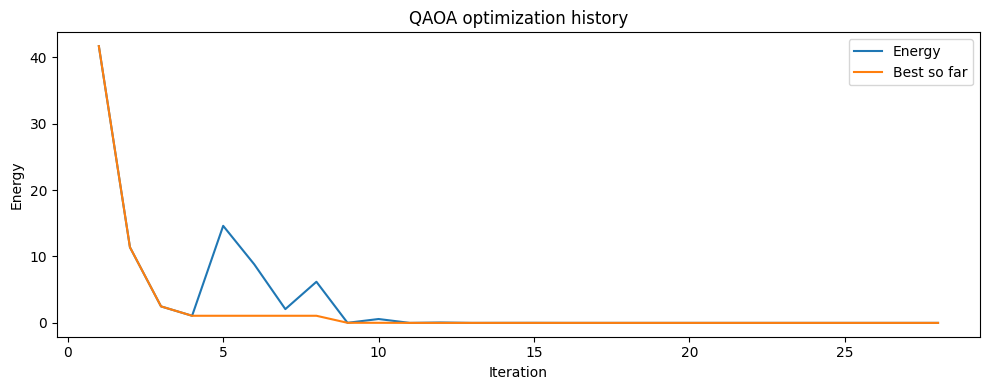

In [12]:
if len(history_df):
    plt.figure(figsize=(10, 4))
    plt.plot(history_df["iteration"], history_df["energy"], label="Energy")
    plt.plot(history_df["iteration"], history_df["best_energy"], label="Best so far")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.title("QAOA optimization history")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
candidate_cols = [
    "bitstring", "source", "probability", "qubo_value",
    "return_term", "risk_term", "budget_term", "exclusivity_term", "qubo_reconstructed",
    "avg_return_term_per_option", "avg_risk_term_per_option", "avg_budget_term_per_option", "avg_exclusivity_term_per_option",
    "selected_usd", "budget_gap", "abs_budget_gap", "num_options", "num_distinct_assets",
    "portfolio_return", "portfolio_vol", "sharpe_like", "max_position_usd"
]

classical_pool = classical_results.head(300).copy()
qaoa_pool = samples_df.head(500).copy() if len(samples_df) else samples_df.copy()

combined = pd.concat([
    classical_pool[candidate_cols],
    qaoa_pool[candidate_cols],
], ignore_index=True)

combined = sort_candidates(combined).drop_duplicates(subset=["bitstring"], keep="first").reset_index(drop=True)
overview_df = sort_candidates(combined).head(TOP_N_EXPORT).copy()
overview_df.insert(0, "rank", range(1, len(overview_df) + 1))
display(overview_df)


,rank,bitstring,source,probability,qubo_value,return_term,risk_term,budget_term,exclusivity_term,qubo_reconstructed,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,1,011111001000000000110000,qaoa_full_pennylane_p1,5.957181e-08,0.372590,-0.163783,0.536366,7.051122e-06,0.0,0.372590,...,0.0,1.000376e+06,375.529549,375.529549,8,5,0.952363,0.190310,4.794093,150115.681396
1,2,101111000100000000110000,qaoa_full_pennylane_p1,5.956667e-08,0.374101,-0.205829,0.579929,1.458854e-06,0.0,0.374101,...,0.0,1.000171e+06,170.812981,170.812981,8,5,1.186816,0.197928,5.794113,150115.681396
2,3,001111100100000000110000,qaoa_full_pennylane_p1,5.956757e-08,0.387095,-0.212914,0.600009,3.307291e-07,0.0,0.387095,...,0.0,1.000081e+06,81.330086,81.330086,8,5,1.226397,0.201343,5.892408,150115.681396
3,4,001111011000000000110000,qaoa_full_pennylane_p1,5.957153e-08,0.396567,-0.174486,0.571038,1.462811e-05,0.0,0.396567,...,0.0,1.000541e+06,540.890144,540.890144,8,5,1.011821,0.196332,4.949879,150136.795410
4,5,001111000100000000110010,qaoa_full_pennylane_p1,5.956402e-08,0.397703,-0.220768,0.618413,5.704868e-05,0.0,0.397703,...,0.0,1.001068e+06,1068.163704,1068.163704,8,5,1.268948,0.204207,6.018161,150115.681396
5,6,001111001000000000110001,qaoa_full_pennylane_p1,5.957158e-08,0.399593,-0.185649,0.585242,6.762197e-07,0.0,0.399593,...,0.0,9.998837e+05,-116.294426,116.294426,8,5,1.074679,0.198890,5.202279,150115.681396
6,7,011111000000001000110000,qaoa_full_pennylane_p1,5.957329e-08,0.400095,-0.118420,0.518514,4.984748e-07,0.0,0.400095,...,0.0,1.000100e+06,99.847359,99.847359,8,5,0.699845,0.187168,3.525422,150115.681396
7,8,001111000100000010110000,qaoa_full_pennylane_p1,5.956657e-08,0.401317,-0.234633,0.635946,3.188741e-06,0.0,0.401317,...,0.0,1.000253e+06,252.536751,252.536751,8,5,1.347194,0.207250,6.307332,150115.681396
8,9,001111000100000000111000,qaoa_full_pennylane_p1,5.956238e-08,0.401390,-0.223057,0.624440,6.726459e-06,0.0,0.401390,...,0.0,1.000367e+06,366.782204,366.782204,8,5,1.282563,0.205343,6.051157,150115.681396
9,10,011111000000000010110000,qaoa_full_pennylane_p1,5.956731e-08,0.403422,-0.108007,0.511426,2.202824e-06,0.0,0.403422,...,0.0,1.000210e+06,209.896370,209.896370,8,5,0.641756,0.185864,3.237621,150115.681396


In [14]:
exploded_rows = []
for _, row in overview_df.iterrows():
    bitstring = row["bitstring"]
    source = row["source"]
    rank = int(row["rank"])
    bitvec = np.array(list(map(int, bitstring)), dtype=int)
    exploded_rows.extend(
        exploded_portfolio_rows(rank, source, bitstring, bitvec, blocks_df, Q, constant, qubo_meta, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
    )

portfolios_df = pd.DataFrame(exploded_rows)
display(portfolios_df.head(40))


,rank,source,bitstring,Ticker,Company,Block Label,Shares,Approx Cost USD,Expected Return Proxy,Annual Volatility,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,1,qaoa_full_pennylane_p1,011111001000000000110000,NVDA,NVIDIA,150k,752,149971.434814,0.909054,0.341897,...,0.0,1.000376e+06,375.529549,375.529549,8,5,0.952363,0.190310,4.794093,150115.681396
1,1,qaoa_full_pennylane_p1,011111001000000000110000,AAPL,Apple,100k,381,99989.640930,0.356791,0.235374,...,0.0,1.000376e+06,375.529549,375.529549,8,5,0.952363,0.190310,4.794093,150115.681396
2,1,qaoa_full_pennylane_p1,011111001000000000110000,AAPL,Apple,150k,572,150115.681396,0.356791,0.235374,...,0.0,1.000376e+06,375.529549,375.529549,8,5,0.952363,0.190310,4.794093,150115.681396
3,1,qaoa_full_pennylane_p1,011111001000000000110000,MSFT,Microsoft,100k,240,100055.998535,0.130464,0.244579,...,0.0,1.000376e+06,375.529549,375.529549,8,5,0.952363,0.190310,4.794093,150115.681396
4,1,qaoa_full_pennylane_p1,011111001000000000110000,MSFT,Microsoft,150k,360,150083.997803,0.130464,0.244579,...,0.0,1.000376e+06,375.529549,375.529549,8,5,0.952363,0.190310,4.794093,150115.681396
5,1,qaoa_full_pennylane_p1,011111001000000000110000,MU,Micron Technology,100k,219,100161.836792,5.612645,0.589799,...,0.0,1.000376e+06,375.529549,375.529549,8,5,0.952363,0.190310,4.794093,150115.681396
6,1,qaoa_full_pennylane_p1,011111001000000000110000,CSCO,Cisco,100k,1200,100032.119751,0.529391,0.251681,...,0.0,1.000376e+06,375.529549,375.529549,8,5,0.952363,0.190310,4.794093,150115.681396
7,1,qaoa_full_pennylane_p1,011111001000000000110000,CSCO,Cisco,150k,1799,149964.819527,0.529391,0.251681,...,0.0,1.000376e+06,375.529549,375.529549,8,5,0.952363,0.190310,4.794093,150115.681396
8,2,qaoa_full_pennylane_p1,101111000100000000110000,NVDA,NVIDIA,100k,501,99914.479843,0.909054,0.341897,...,0.0,1.000171e+06,170.812981,170.812981,8,5,1.186816,0.197928,5.794113,150115.681396
9,2,qaoa_full_pennylane_p1,101111000100000000110000,AAPL,Apple,100k,381,99989.640930,0.356791,0.235374,...,0.0,1.000171e+06,170.812981,170.812981,8,5,1.186816,0.197928,5.794113,150115.681396


In [15]:
best_classical = sort_candidates(classical_results).head(1).copy()
solver_frames = [best_classical.assign(solver="Classical Heuristic")]

if len(samples_df):
    best_qaoa = sort_candidates(samples_df).head(1).copy()
    solver_frames.append(best_qaoa.assign(solver=f"Full QAOA PennyLane p={QAOA_P}"))

solver_comparison_df = pd.concat(solver_frames, ignore_index=True)
solver_comparison_df = solver_comparison_df[[
    "solver", "bitstring", "qubo_value",
    "return_term", "risk_term", "budget_term", "exclusivity_term", "qubo_reconstructed",
    "avg_return_term_per_option", "avg_risk_term_per_option", "avg_budget_term_per_option", "avg_exclusivity_term_per_option",
    "selected_usd", "budget_gap", "abs_budget_gap", "num_options", "num_distinct_assets",
    "portfolio_return", "portfolio_vol", "sharpe_like", "max_position_usd"
]]
display(solver_comparison_df)


,solver,bitstring,qubo_value,return_term,risk_term,budget_term,exclusivity_term,qubo_reconstructed,avg_return_term_per_option,avg_risk_term_per_option,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,Classical Heuristic,111111100000000000010000,0.482913,-0.093085,0.575997,3.116567e-07,0.0,0.482913,-0.011636,0.072000,...,0.0,9.999210e+05,-78.950203,78.950203,8,5,0.558769,0.197305,2.629274,150115.681396
1,Full QAOA PennyLane p=1,011111001000000000110000,0.372590,-0.163783,0.536366,7.051122e-06,0.0,0.372590,-0.020473,0.067046,...,0.0,1.000376e+06,375.529549,375.529549,8,5,0.952363,0.190310,4.794093,150115.681396


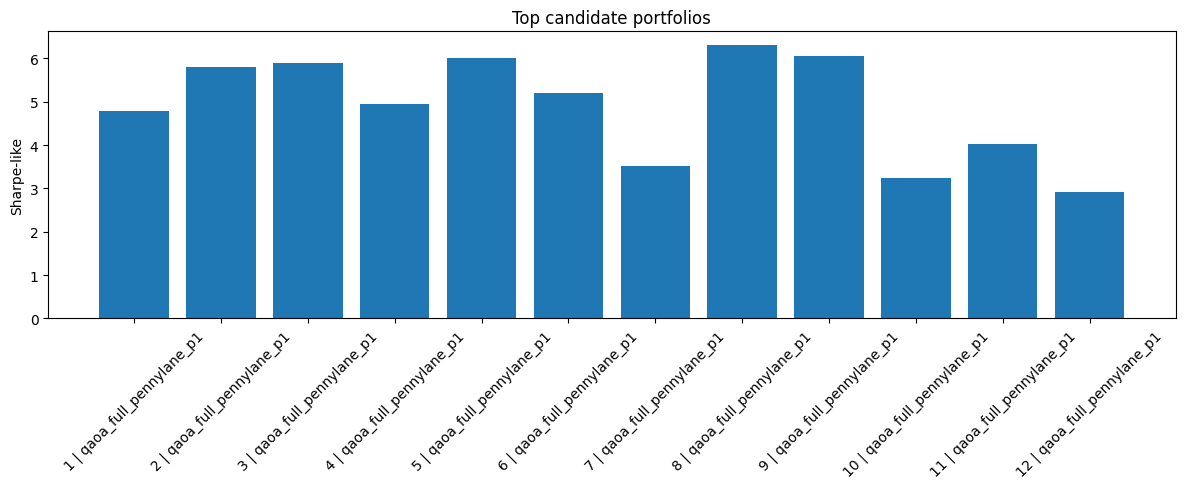

In [16]:
top_plot = overview_df.head(12).copy()
labels = top_plot["rank"].astype(str) + " | " + top_plot["source"].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(labels, top_plot["sharpe_like"])
plt.xticks(rotation=45)
plt.ylabel("Sharpe-like")
plt.title("Top candidate portfolios")
plt.tight_layout()
plt.show()

In [17]:
def write_df(ws, df, dark_fill, white_bold):
    for j, col in enumerate(df.columns, start=1):
        ws.cell(1, j, col)
        ws.cell(1, j).fill = dark_fill
        ws.cell(1, j).font = white_bold
    for i, row in enumerate(df.itertuples(index=False), start=2):
        for j, val in enumerate(row, start=1):
            ws.cell(i, j, val)

def write_results(xlsx_path, overview_df, portfolios_df, solver_comparison_df, classical_results, samples_df, history_df, best_gammas, best_betas, qaoa_p):
    wb = load_workbook(xlsx_path)

    for name in ["Results_Summary", "Results_Overview", "Results_Portfolios", "QAOA_Samples", "Classical_Candidates", "Solver_Comparison", "Optimization_History"]:
        if name in wb.sheetnames:
            wb.remove(wb[name])

    dark = PatternFill("solid", fgColor="1F4E78")
    white_bold = Font(color="FFFFFF", bold=True)

    summary_ws = wb.create_sheet("Results_Summary")
    summary_ws["A1"] = "Results summary"
    summary_ws["A1"].fill = dark
    summary_ws["A1"].font = white_bold

    summary_items = [
        ("Top-N exported", int(len(overview_df))),
        ("Classical candidate count", int(len(classical_results))),
        ("QAOA candidate count", int(len(samples_df))),
        ("QAOA p", int(qaoa_p)),
    ]
    summary_items += [(f"QAOA gamma_{i+1}", float(best_gammas[i]) if i < len(best_gammas) and np.isfinite(best_gammas[i]) else None) for i in range(qaoa_p)]
    summary_items += [(f"QAOA beta_{i+1}", float(best_betas[i]) if i < len(best_betas) and np.isfinite(best_betas[i]) else None) for i in range(qaoa_p)]
    summary_items += [
        ("Best overview Sharpe-like", float(overview_df["sharpe_like"].max()) if len(overview_df) else None),
        ("Best overview invested USD", float(overview_df.iloc[0]["selected_usd"]) if len(overview_df) else None),
        ("Best overview abs budget gap", float(overview_df.iloc[0]["abs_budget_gap"]) if len(overview_df) else None),
        ("Best overview return term", float(overview_df.iloc[0]["return_term"]) if len(overview_df) else None),
        ("Best overview risk term", float(overview_df.iloc[0]["risk_term"]) if len(overview_df) else None),
        ("Best overview budget term", float(overview_df.iloc[0]["budget_term"]) if len(overview_df) else None),
        ("Best overview exclusivity term", float(overview_df.iloc[0]["exclusivity_term"]) if len(overview_df) else None),
        ("Optimization iterations", int(len(history_df))),
    ]
    for i, (label, value) in enumerate(summary_items, start=2):
        summary_ws.cell(i, 1, label)
        summary_ws.cell(i, 2, value)

    overview_ws = wb.create_sheet("Results_Overview")
    write_df(overview_ws, overview_df, dark, white_bold)

    portfolios_ws = wb.create_sheet("Results_Portfolios")
    write_df(portfolios_ws, portfolios_df, dark, white_bold)

    qaoa_ws = wb.create_sheet("QAOA_Samples")
    write_df(qaoa_ws, samples_df.head(500), dark, white_bold)

    classical_ws = wb.create_sheet("Classical_Candidates")
    write_df(classical_ws, classical_results.head(500), dark, white_bold)

    solver_ws = wb.create_sheet("Solver_Comparison")
    write_df(solver_ws, solver_comparison_df, dark, white_bold)

    hist_ws = wb.create_sheet("Optimization_History")
    write_df(hist_ws, history_df, dark, white_bold)

    out_path = xlsx_path.with_name(xlsx_path.stem + f"_pennylane_p{qaoa_p}_noblockconstraint.xlsx")
    wb.save(out_path)
    return out_path

out_path = write_results(
    xlsx_path=xlsx_path,
    overview_df=overview_df,
    portfolios_df=portfolios_df,
    solver_comparison_df=solver_comparison_df,
    classical_results=classical_results,
    samples_df=samples_df,
    history_df=history_df,
    best_gammas=best_gammas,
    best_betas=best_betas,
    qaoa_p=QAOA_P,
)

print(f"Saved workbook with results to: {out_path.resolve()}")


Saved workbook with results to: /Users/danielhug/code/qubit-lab/QAOA-Optimizer/demo_budget_block_options_12sec_pennylane_p2_splitterms_pennylane_p1_noblockconstraint.xlsx
